In [30]:
import pandas as pd
import matplotlib.pyplot as plt

#Reading the dataset

In [72]:
#Reading the data by setting garbage values in age as NULL to prevent errors
df=pd.read_csv('set1data.csv',na_values=['Null',-90,'?',999,-98])
df

,Unnamed: 0,id,age,salary,bought TV
0,0,1,51.0,8241.0,1
1,1,2,33.0,68076.0,0
2,2,3,41.0,7876.0,0
3,3,4,60.0,94066.0,1
4,4,5,58.0,37654.0,0
...,...,...,...,...,...
395,395,396,50.0,61700.0,1
396,396,397,45.0,2630.0,1
397,397,398,53.0,68894.0,1
398,398,399,NaN,16818.0,0


In [73]:
df.columns

Index(['Unnamed: 0', 'id', 'age', 'salary', 'bought TV'], dtype='object')

In [74]:
df.dtypes

Unnamed: 0      int64
id              int64
age           float64
salary        float64
bought TV       int64
dtype: object

In [75]:
df.describe()

,Unnamed: 0,id,age,salary,bought TV
count,400.000000,400.000000,391.000000,396.000000,400.000000
mean,199.500000,200.500000,38.575448,27883.982323,0.275000
std,115.614301,115.614301,12.263718,31236.075525,0.447073
min,0.000000,1.000000,18.000000,-99999.000000,0.000000
25%,99.750000,100.750000,28.000000,5563.750000,0.000000
50%,199.500000,200.500000,38.000000,9351.000000,0.000000
75%,299.250000,300.250000,49.000000,53482.000000,1.000000
max,399.000000,400.000000,60.000000,98837.000000,1.000000


#Plotting bar chart

<Axes: >

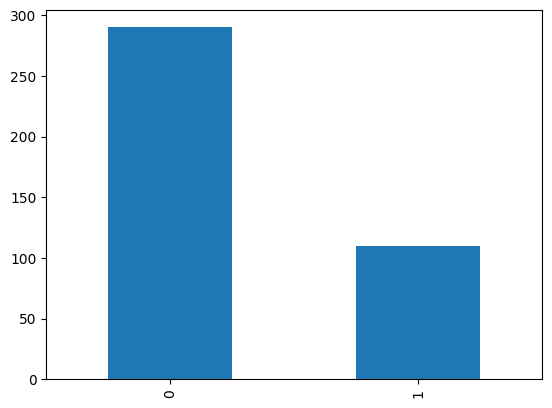

In [76]:
df['bought TV'].value_counts().plot.bar()

#Removing unwanted data from age and salary

In [77]:
df.isnull().sum()

Unnamed: 0    0
id            0
age           9
salary        4
bought TV     0
dtype: int64

In [78]:
df['age'].fillna(df['age'].mode()[0],inplace=True)
df['salary'].fillna(df['salary'].mean(),inplace=True)
df

,Unnamed: 0,id,age,salary,bought TV
0,0,1,51.0,8241.0,1
1,1,2,33.0,68076.0,0
2,2,3,41.0,7876.0,0
3,3,4,60.0,94066.0,1
4,4,5,58.0,37654.0,0
...,...,...,...,...,...
395,395,396,50.0,61700.0,1
396,396,397,45.0,2630.0,1
397,397,398,53.0,68894.0,1
398,398,399,25.0,16818.0,0


In [79]:
df.isnull().sum()

Unnamed: 0    0
id            0
age           0
salary        0
bought TV     0
dtype: int64

In [71]:
#Previously found garbage values in age using this
df.age.value_counts()

25      30
33      15
58      14
53      14
28      14
45      13
34      12
42      12
24      11
38      11
49      11
44      11
35      11
52      11
32      10
26      10
20      10
41       9
50       9
19       9
59       9
23       8
43       8
51       8
56       8
60       8
29       8
31       7
39       7
36       7
37       6
48       6
40       6
57       6
30       6
22       6
18       6
54       6
47       5
27       5
55       4
46       4
21       4
Null     1
-90      1
?        1
-98      1
999      1
Name: age, dtype: int64

#Checking if rescaling is required

<Axes: >

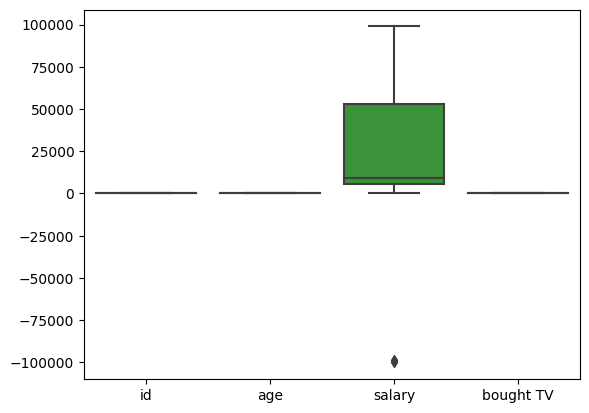

In [82]:
#For scaling the model we check for outliers using boxplot
import seaborn as sns
sns.boxplot(df)
#Since outliers are present re-scaling is required

In [ ]:
#Salary column has outliers so we remove them
import numpy as np
q1=np.quantile(df['salary'],0.25)
q3=np.quantile(df['salary'],0.75)
iqr=q3-q1
min=q1-1.5*iqr
max=q3+1.5*iqr
new_df=df[df['salary']>min & df['salary']<max].copy()
new_df

#Preprocessing and splitting to train and test

In [81]:
df.drop('Unnamed: 0',axis=1,inplace=True)
df

,id,age,salary,bought TV
0,1,51.0,8241.0,1
1,2,33.0,68076.0,0
2,3,41.0,7876.0,0
3,4,60.0,94066.0,1
4,5,58.0,37654.0,0
...,...,...,...,...
395,396,50.0,61700.0,1
396,397,45.0,2630.0,1
397,398,53.0,68894.0,1
398,399,25.0,16818.0,0


In [83]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [84]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.3)

#Applying ML model and result vizualization

In [85]:
#The problem is to find if the a given customer will buy TV or not
from sklearn.tree import DecisionTreeClassifier
mod = DecisionTreeClassifier()
mod.fit(x_train,y_train)

DecisionTreeClassifier()

In [86]:
mod.score(x_test,y_test)

0.8416666666666667

In [87]:
from sklearn.metrics import confusion_matrix
y_pred=mod.predict(x_test)
mat=confusion_matrix(y_test,y_pred)

<Axes: >

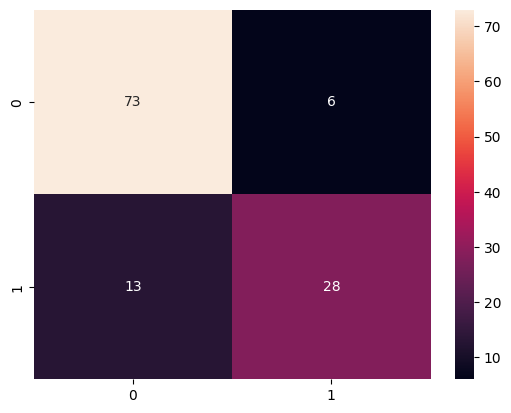

In [91]:
#Vizualization of true positives and true negatives using the heatmap
sns.heatmap(mat,annot=True)